In [ ]:
import numpy as np
import matplotlib.pyplot as plt


from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

[10, 100, 1000, 10000]

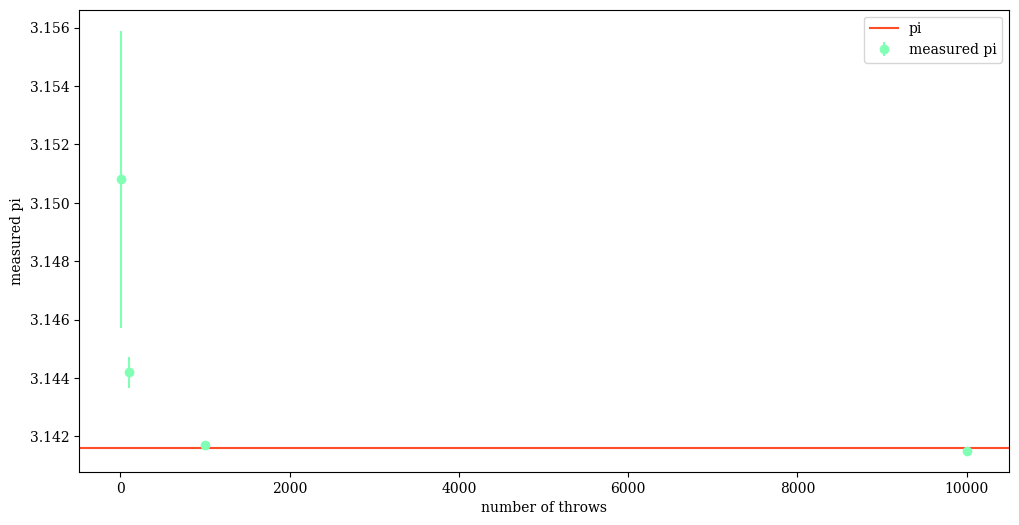

In [81]:
'''
creating a function to calculate the radius of the points

create a function to find out, if point is within a given radius from the origin

create a function to count the number of points within a given radius from the origin

'''
def radius(x,y):
    return np.sqrt(x**2+y**2)

def point_within_radius(r, x, y):
    r_array=radius(x,y)
    return True if r_array<=r else False

def count_points_within_radius(r, x_array, y_array):
    count=0
    for x,y in zip(x_array, y_array):
        if point_within_radius(r, x, y):
            count+=1
    return count


'''
Initializing Parameters
'''

r = np.random
r.seed(42)

N_exp=1000
N_throws=[10,100,1000,10000]#,100000]

measured_pi=np.zeros(N_exp)
points_in=np.zeros(N_exp)

mean_pi=np.zeros(len(N_throws))
unc_pi=np.zeros(len(N_throws))


circle_radius=5.2
sample_boundary=circle_radius



for t, throws in enumerate(N_throws):
    for exp in range(N_exp):

        sum_within_circle=0


        '''generate 2 dimensional data within +-boundary'''

        random_array=r.uniform(low=0, high=sample_boundary, size=(throws,2))


        '''
        plot in histogram


        N_bins=1000

        fig, ax = plt.subplots(figsize=(12, 2))
        counts,edges,_=ax.hist(random_array, bins=N_bins, histtype='step', label='histogram')#, color=my_cmap(0.5))

        '''


        '''
        N_plot=500

        fig, ax = plt.subplots(figsize=(6, 6))

        for i in range(N_plot):
            if point_within_radius(circle_radius, random_array[i,0], random_array[i,1]):
                ax.scatter(random_array[i,0], random_array[i,1], s=10, color=my_cmap(0.9))
            else:
                ax.scatter(random_array[i,0], random_array[i,1], s=10, color=my_cmap(0.1))

            
        ax.set(xlim=(-sample_boundary, sample_boundary), ylim=(-sample_boundary, sample_boundary), xlabel="x", ylabel="y")
        #ax.legend()'''


        '''
        Calculate Pi over the area of the points within the radius in the box
        '''

        points_in[exp]=count_points_within_radius(circle_radius, random_array[:,0], random_array[:,1])
        measured_pi[exp]=(4*points_in[exp]/throws)

    mean_pi[t]=measured_pi.mean()
    unc_pi[t]=measured_pi.std()/np.sqrt(N_exp*N_throws[t])

    #print(f'{measured_pi.mean():.4f}+-{measured_pi.std()/np.sqrt(N_exp):.4f} ')


    #bin_sizes=[3,1,0.1]#3,1,0.1
    #N_bins=[sample_boundary/bin_size for bin_size in bin_sizes]

    #fig, ax = plt.subplots(figsize=(12, 2))
    #xbins = [np.arange(1, 4.5, bin_size) for bin_size in bin_sizes]

    #for asdfds in range(len(bin_sizes)):
    #ax.hist(measured_pi*circle_radius**2, bins=100, histtype='step', label='histogram')#, color=my_cmap(0.5))

fig,ax=plt.subplots(figsize=(12,6))
ax.errorbar(N_throws,mean_pi, yerr=unc_pi, fmt='o', color=my_cmap(0.5), label='measured pi')
ax.axhline(np.pi, color=my_cmap(0.9), label='pi')
ax.set(ylabel='measured pi', xlabel='number of throws')
ax.legend()

N_throws